# Importante: Validación , Callback y Poner un subplot comparando otros modelos

# Importante v2: Mirar Libreta3 si es CLASIFICACIÓN (Multiple) y NO REGRESIÓN

# Importante v3: Mirar Diabetes si es CLASIFICACIÓN (Binaria) y NO REGRESIÓN

# Práctica: Análisis de Datos de Hormigón y Redes Neuronales

Este notebook te guiará a través del proceso de carga de datos, ingeniería de características y construcción de modelos de Deep Learning con Keras.

### 1. Carga y Análisis Inicial de Datos

**Instrucciones:**
1. Importa las librerías necesarias (pandas, numpy, seaborn, matplotlib, etc.).
2. Carga el archivo de datos en un DataFrame de Pandas llamado `concrete_data`.
3. Analiza los datos iniciales para comprender su estructura y características principales (usa `.head()`, `.info()`).

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar dataframe
df = pd.read_csv('/content/drive/MyDrive/Datasets/concrete_data.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


### 2. Ingeniería de Características (Feature Engineering)

**Instrucciones:**
Añade una nueva característica al DataFrame:

* Calcula una nueva columna llamada **"WC Ratio"** (relación agua/cemento).
* Esta se define como el cociente entre las columnas `Water` y `Cement`.

```python
concrete_data['WC Ratio'] = concrete_data['Water'] / concrete_data['Cement']
```

In [ ]:
df["WC Ratio"] = df["Water"] / df["Cement"]

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,WC Ratio
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767


### 3. Preguntas sobre los Datos

Responde a las siguientes preguntas mediante código:
1.  ¿Cuántas filas y columnas tiene el DataFrame?
2.  ¿Faltan datos en el conjunto? En caso afirmativo, identifica las columnas afectadas.

In [ ]:
df.info()
# Tiene un total de 10 columnas y 1030 filas

print("\n ============== \n")

df.isnull().sum()

# No, no tiene valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
 9   WC Ratio            1030 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 80.6 KB




,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0
WC Ratio,0


### 4. Estadísticas Descriptivas y Visualización

**Instrucciones:**
1.  **Estadísticas:** Genera y revisa las estadísticas descriptivas del conjunto de datos para entender la distribución de las características (usa `.describe()`).
2.  **Visualización:** Visualiza la distribución de las características utilizando gráficos (histogramas, boxplots) para identificar patrones o tendencias.

In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength,WC Ratio
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961,0.748266
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742,0.314005
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000,0.266893
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000,0.533333
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000,0.675349
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000,0.935165
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000,1.882353


### 5. Visualización

**Instrucciones:**
1.  **Visualización:** Visualiza la distribución de las características utilizando gráficos (histogramas, boxplots) para identificar patrones o tendencias.

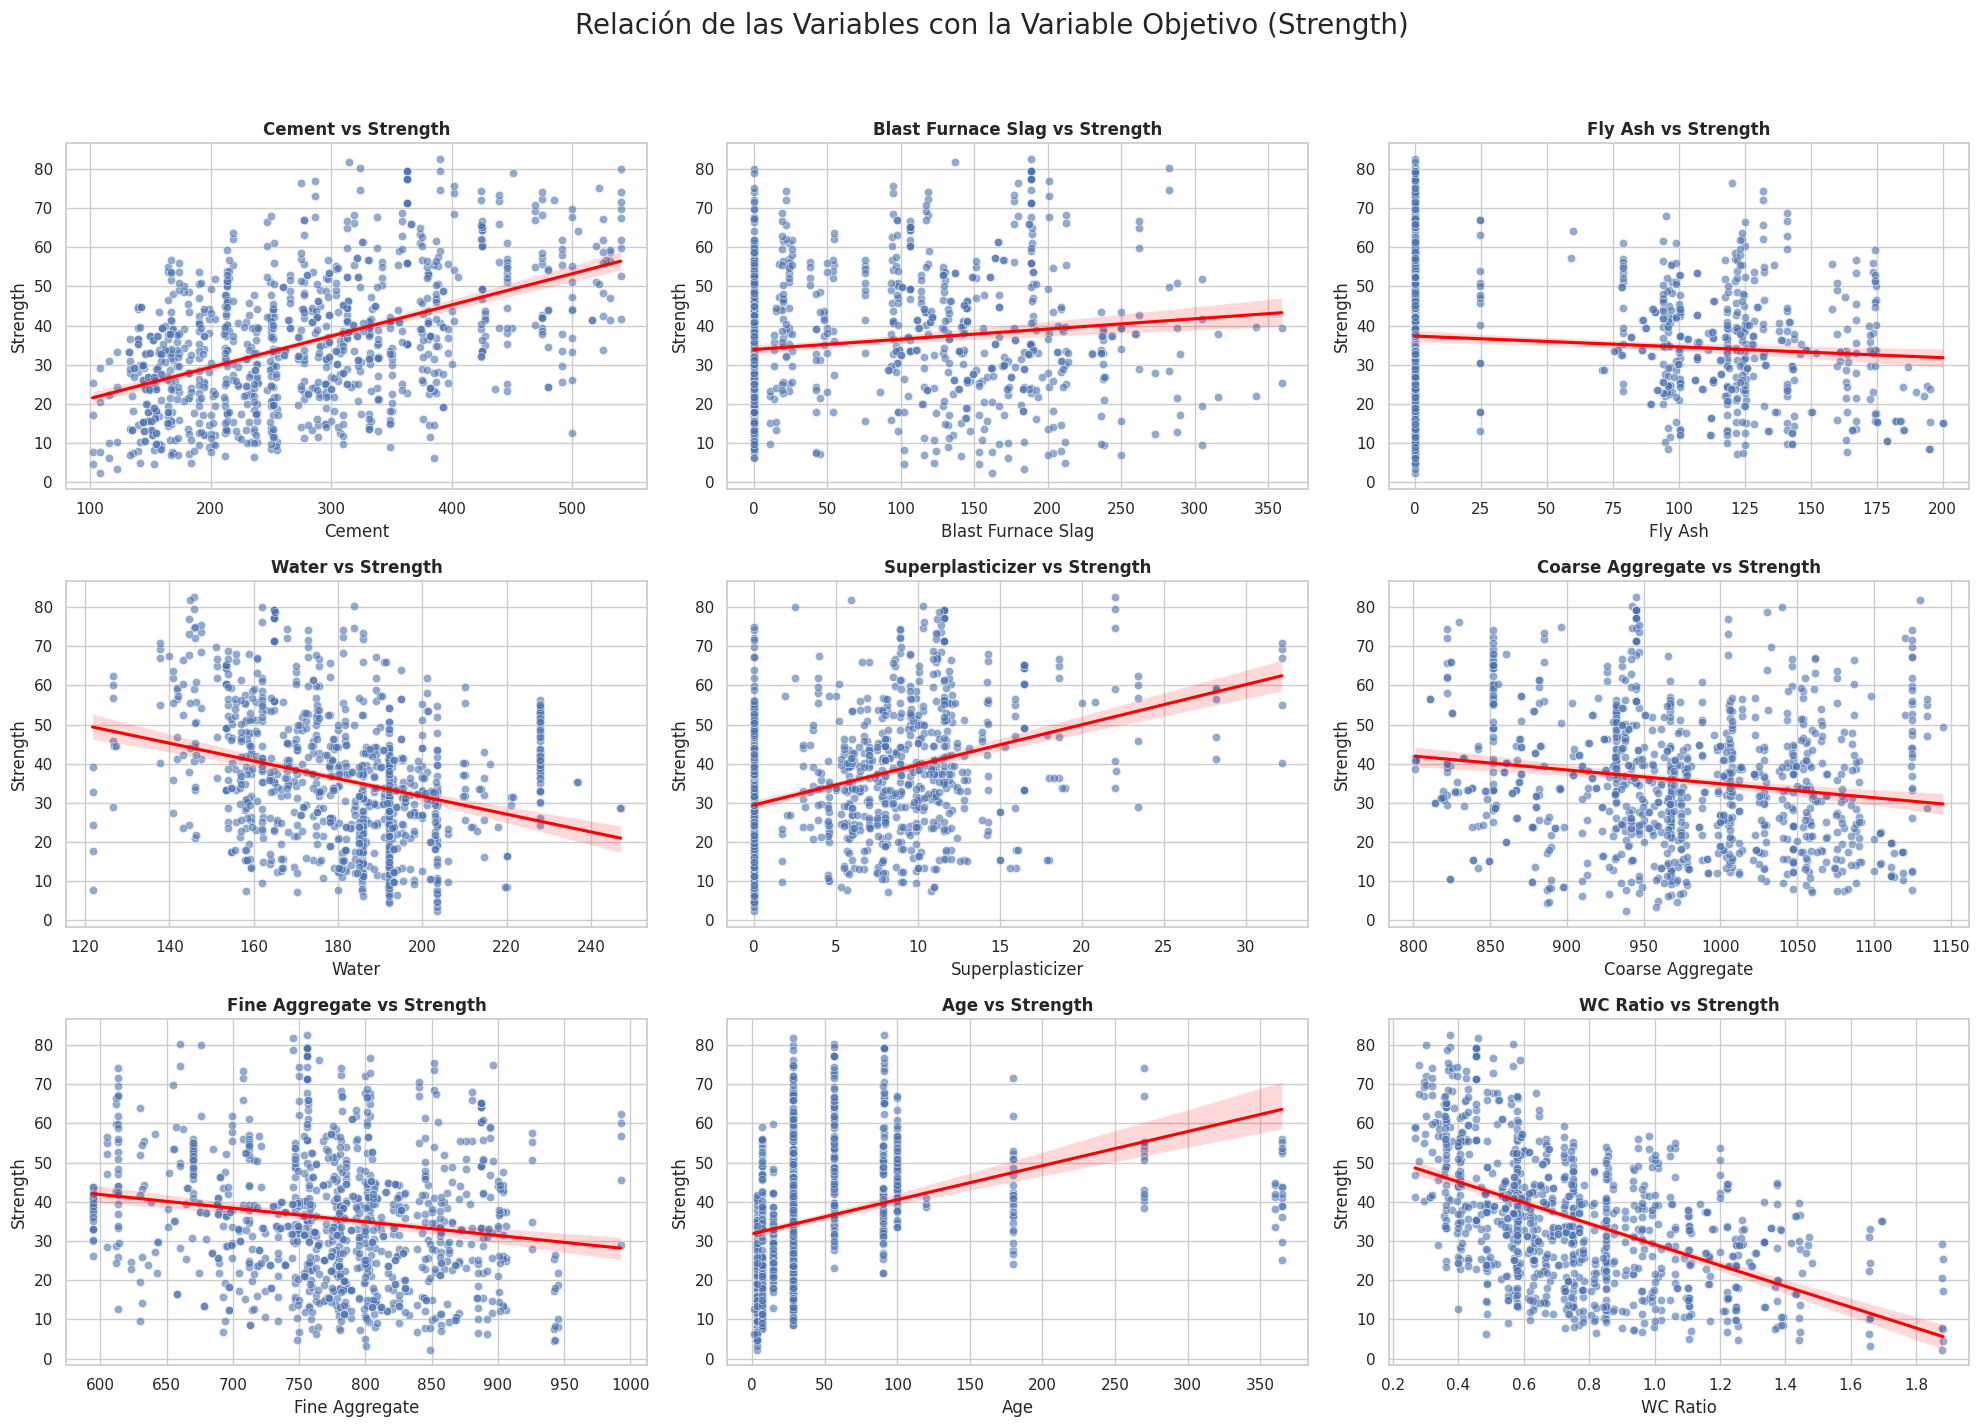

In [ ]:
# Configuración de estilo visual
sns.set(style="whitegrid")

# 1. Definir las variables (Columnas)
features = [
    'Cement',
    'Blast Furnace Slag',
    'Fly Ash',
    'Water',
    'Superplasticizer',
    'Coarse Aggregate',
    'Fine Aggregate',
    'Age',
    'WC Ratio'
]

target = 'Strength'

# 2. Configurar el tamaño de la figura y la cuadrícula (3 filas x 3 columnas = 9 gráficos)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
fig.suptitle('Relación de las Variables con la Variable Objetivo (Strength)', fontsize=20)

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# 3. Generar los gráficos
for i, col in enumerate(features):
    # Crear el Scatter Plot
    sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6, color='b')

    # Añadir línea de regresión (opcional, ayuda a ver la tendencia)
    sns.regplot(data=df, x=col, y=target, ax=axes[i], scatter=False, color='red')

    # Títulos y etiquetas
    axes[i].set_title(f'{col} vs {target}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# Ajustar el espacio entre gráficos para que no se solapen
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Mostrar
plt.show()

### 6. Construcción de una Red Neuronal Inicial

**Instrucciones:**
Usa la biblioteca **Keras** para crear una red neuronal con las siguientes especificaciones:

* **Estructura:** Una capa oculta con 10 nodos y función de activación ReLU.
* **Salida:** 1 nodo (para regresión).
* **Optimizador:** ADAM.
* **Función de pérdida:** Mean Squared Error (MSE).

*Recuerda separar primero los datos en predictores (X) y objetivo (y).*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
import tensorflow as tf

# Muestras
X = df.drop("Strength", axis=1)
y = df["Strength"]

# Separar los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalar los datos
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

# Construir el Modelo
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(10, activation='relu'),
    Dense(1)
])

# Compilar el Modelo
model.compile(optimizer=Adam(), loss='mse')


# Entrenar el modelo
history_without_normalize = model.fit(X_train, y_train, epochs=50)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 27836.9336
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7450.9570 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2474.0420
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1311.6602 
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 939.2874
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 834.8032
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 727.5126
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 679.8508 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 664.1346
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 531.2966 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 551.0533 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 516.7669
Epoch 13/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 446.1917
Epoch 14/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 474.4201 
Epoch 15/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

### 7. Normalización de Datos

**Instrucciones:**
1.  Normaliza las variables predictoras restando la media y dividiendo entre la desviación estándar.
2.  Usa este conjunto normalizado para construir y entrenar una nueva red neuronal (misma arquitectura que arriba).

In [ ]:
# Normalización
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_test_norm = (X_test - X_train.mean()) / X_train.std()

In [ ]:
# Construir el Modelo
model = Sequential([
    Input(shape=(X_train_norm.shape[1],)),
    Dense(10, activation='relu'),
    Dense(1)
])

# Compilar el Modelo
model.compile(optimizer=Adam(), loss='mse')

# Entrenar el modelo
#history = model.fit(X_train_norm, y_train, epochs=50)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1660.1160
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1572.6232
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1481.9390
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1464.8934 
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1432.3928 
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1457.8123
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1370.1212 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1416.0393 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1314.9230
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1361.4023
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1349.3156 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1265.5323 
Epoch 13/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1170.6768
Epoch 14/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1145.2155
Epoch 15/50
26/26 ━━━━━━━━━━━━━━━━━━

### 8. Mejoras en la Red Neuronal y Gráficos

**Instrucciones:**
1.  **Mejora:** Aumenta el número de capas en la red neuronal o nodos y ajusta su arquitectura.
2.  **Entrenamiento:** Entrena el modelo guardando el historial (`history = model.fit(...)`).

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Mejoras
model = Sequential([
    Input(shape=(X_train_norm.shape[1],)),
    Dense(10, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
    # Si es de clasificación la última capa tiene que ser de activacion="softmax"
    #y el número sería el número de clasificaciones (Ej: 3 -> Avión, Coche, Casa)
])

# Callbacks

# Detiene el entrenamiento si la validación deja de mejorar.
# Evita sobreentrenamiento y ahorra tiempo.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Reduce la tasa de aprendizaje automáticamente cuando la validación se estanca.
# Ayuda a que el modelo siga mejorando en fases tardías del entrenamiento.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Compilar el Modelo
model.compile(optimizer=Adam(), loss='mse') # En clasificación se cambia por accuracy

# Entrenar el modelo
history = model.fit(
    X_train_norm, y_train,
    validation_split=0.2,         # 20% de los datos se reservan para validación
    epochs=50,
    callbacks=[early_stop, reduce_lr],  # Se activan ambos callbacks
    verbose=1
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 1505.1981 - val_loss: 1468.2716 - learning_rate: 0.0010
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1430.9741 - val_loss: 1286.5752 - learning_rate: 0.0010
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1194.7075 - val_loss: 949.8002 - learning_rate: 0.0010
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 849.0507 - val_loss: 510.1669 - learning_rate: 0.0010
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 455.2371 - val_loss: 288.3991 - learning_rate: 0.0010
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 332.0833 - val_loss: 248.0645 - learning_rate: 0.0010
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 300.9940 - val_loss: 231.8925 - learning_rate: 0.0010
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 265.8268 - val_loss: 220.5975 - learning_rate: 0.0010
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 240.9713 - val_loss: 207.4460 - learning

In [ ]:
# Evaluar el modelo

results = model.evaluate(X_test_norm, y_test)
print('Test loss', results)

# Cuanto menos test lost mejor
# Cuanto más accuracy mejor

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 107.5317
Test loss 106.29754638671875


In [ ]:
# Predecir los 2 primeros

y_pred = model.predict(X_test_norm[:5])
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


array([[51.430756],
       [55.219753],
       [68.93913 ],
       [54.649372],
       [18.829636]], dtype=float32)

In [ ]:
# Comprobar exactitud predicción
y_test[:5]

,Strength
31,52.91
109,55.90
136,74.50
88,35.30
918,10.54


### 9. Representación Gráfica del Progreso:

**Instrucciones:**
1.  **Gráficos:** Dibuja gráficos que muestren cómo evoluciona la pérdida (loss) durante el entrenamiento.

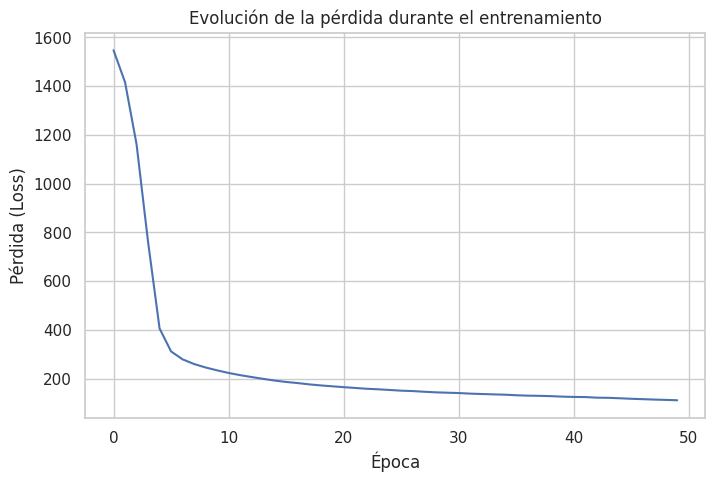

In [ ]:
# Extraer valores de pérdida
loss = history.history["loss"]

# Estilo visual
sns.set(style="whitegrid")

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(loss)
plt.xlabel("Época")
plt.ylabel("Pérdida (Loss)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()

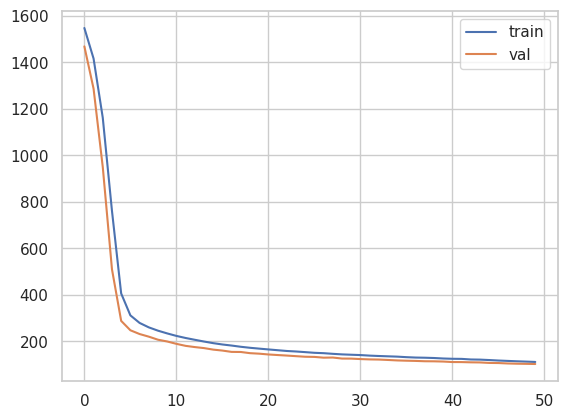

In [ ]:
history.history['val_loss']


plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

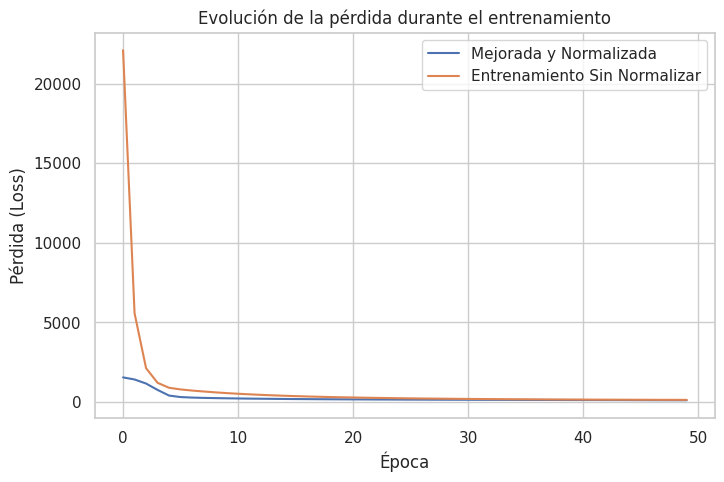

In [ ]:
# Extraer valores de pérdida
loss = history.history["loss"]


# Estilo visual
sns.set(style="whitegrid")

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(loss, label="Mejorada y Normalizada")
plt.plot(history_without_normalize.history["loss"], label='Entrenamiento Sin Normalizar')
plt.legend()
plt.xlabel("Época")
plt.ylabel("Pérdida (Loss)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()